## Video Game Market Dashboard — Global Analysis (1980–2016)

This notebook presents an exploratory analysis of global video game sales from 1980 to 2016.  
The goal is to identify market trends, platform dominance, regional preferences, and score perception gaps across genres.

**Dataset:** Video Game Sales (16,719 titles) | **Source:** Kaggle  
**Tools:** Python, Pandas, Plotly

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import warnings

warnings.filterwarnings("ignore")

# Load the dataset
df = pd.read_csv(r"C:\Python\Portfolio\Videogames sales\Video_Games_Sales_as_at_22_Dec_2016.csv")

# Set the style and figure size for the plot
sns.set_style("darkgrid")
plt.figure(figsize=(14, 6))


<Figure size 1400x600 with 0 Axes>

<Figure size 1400x600 with 0 Axes>

In [2]:
print(df.shape)
df.head()

(16719, 16)


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16719 non-null  object 
 2   Year_of_Release  16450 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16665 non-null  object 
 5   NA_Sales         16719 non-null  float64
 6   EU_Sales         16719 non-null  float64
 7   JP_Sales         16719 non-null  float64
 8   Other_Sales      16719 non-null  float64
 9   Global_Sales     16719 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       10015 non-null  object 
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  object 
 15  Rating           9950 non-null   object 
dtypes: float64(9), object(7)
memory usage: 2.0+ MB


In [4]:
df1 = df.copy()

In [5]:
print(df1["User_Score"].unique()[:20])

['8' nan '8.3' '8.5' '6.6' '8.4' '8.6' '7.7' '6.3' '7.4' '8.2' '9' '7.9'
 '8.1' '8.7' '7.1' '3.4' '5.3' '4.8' '3.2']


In [6]:
#Replace "tbd" with NaN and convert to numeric
df1["User_Score"] = pd.to_numeric(df1["User_Score"].replace("tbd", pd.NA), errors="coerce")

#remove unnecessary decimals from year of release and convert to integer
df1["Year_of_Release"] = df1["Year_of_Release"].astype("Int64")

# check results
df1[["User_Score", "Year_of_Release", "Critic_Score"]].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   User_Score       7590 non-null   float64
 1   Year_of_Release  16450 non-null  Int64  
 2   Critic_Score     8137 non-null   float64
dtypes: Int64(1), float64(2)
memory usage: 408.3 KB


In [7]:
#invalid data in User_Score and Year_of_Release has been handled. Now we can check for null values in the dataset.

nulls = df1.isnull().sum()
nulls_percent = (nulls / len(df1) * 100).round(1)

null_count = pd.DataFrame({
    "Null Count": nulls,
    "Null Percentage": nulls_percent
}).query("`Null Count` > 0").sort_values("Null Percentage", ascending=False)

display(null_count)

,Null Count,Null Percentage
User_Score,9129,54.6
User_Count,9129,54.6
Critic_Count,8582,51.3
Critic_Score,8582,51.3
Rating,6769,40.5
Developer,6623,39.6
Year_of_Release,269,1.6
Publisher,54,0.3
Name,2,0.0
Genre,2,0.0


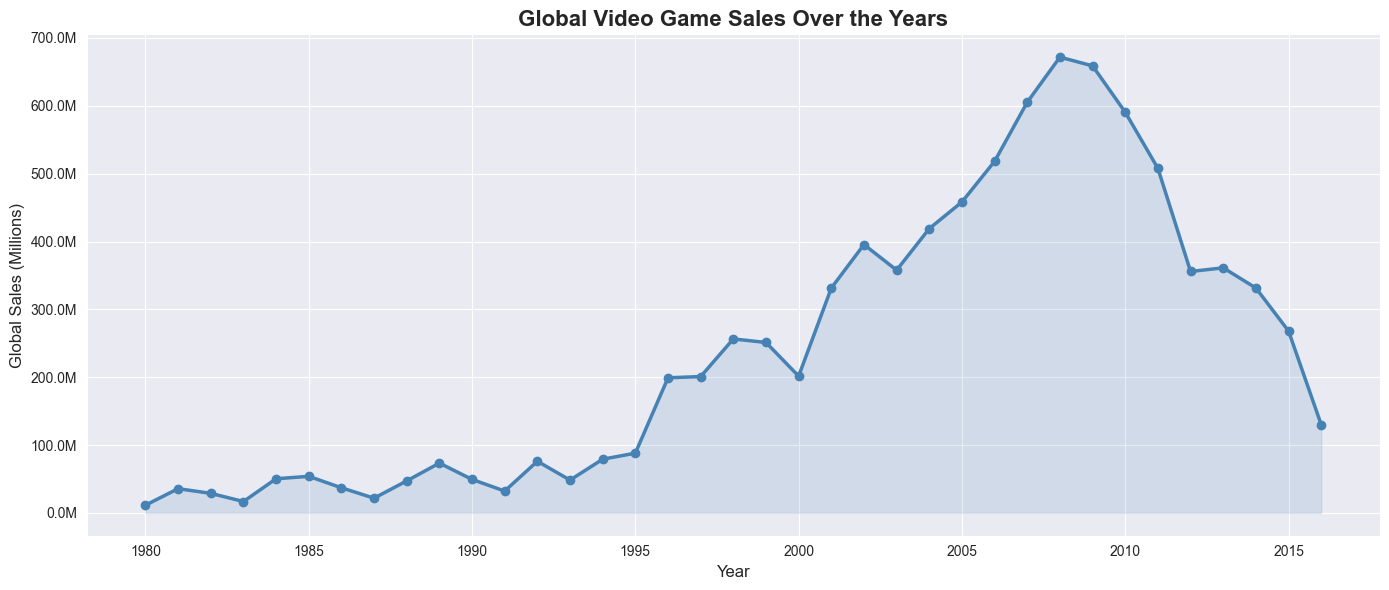

In [8]:
# Timeseries plot of global sales over the years

# filtering rows without a year and years that are out of range
df_time = df1[df1["Year_of_Release"].notna() & (df1["Year_of_Release"]<=2016)]

# Grouping by year and summing global sales
sales_by_year = df_time.groupby("Year_of_Release")["Global_Sales"].sum().reset_index()

# Plotting the timeseries
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(sales_by_year["Year_of_Release"],
        sales_by_year["Global_Sales"],
        color="steelblue", linewidth=2.5, marker="o", markersize=6)

ax.fill_between(sales_by_year["Year_of_Release"],
                sales_by_year["Global_Sales"],
                alpha=0.15, color="steelblue")

ax.set_title("Global Video Game Sales Over the Years", fontsize=16, fontweight="bold")
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Global Sales (Millions)", fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}M"))

plt.tight_layout()
plt.show()

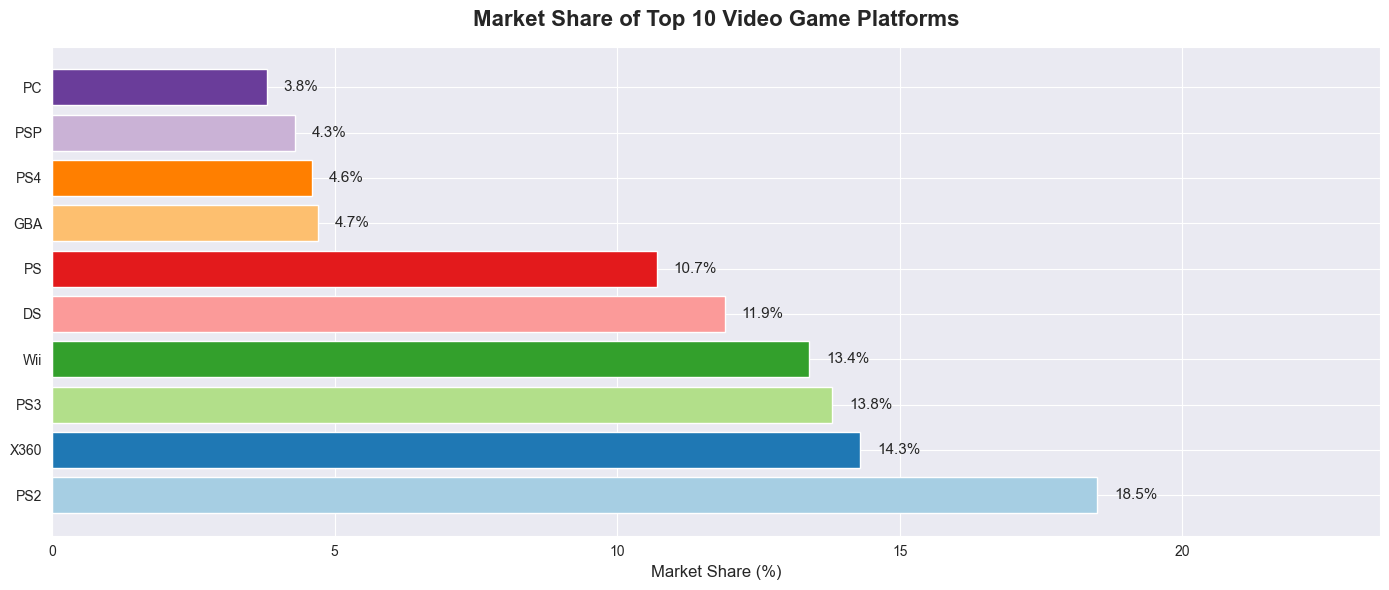

In [9]:
#Market share by platform
#Top 10 platforms by global sales
platform_sales = df1.groupby("Platform")["Global_Sales"].sum().sort_values(ascending=False).head(10).reset_index()

#Calculate percentage
platform_sales["Market_Sahre"] = (platform_sales["Global_Sales"] / platform_sales["Global_Sales"].sum() * 100).round(1)

# Plotting
fig, ax = plt.subplots(figsize=(14, 6))

bars =ax.barh(platform_sales["Platform"], platform_sales["Market_Sahre"], color=sns.color_palette("Paired", len(platform_sales)))
for bar, pct in zip(bars, platform_sales["Market_Sahre"]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2, f"{pct}%", va="center", fontsize=11)

ax.set_title("Market Share of Top 10 Video Game Platforms", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Market Share (%)", fontsize=12)
ax.set_xlim(0, platform_sales["Market_Sahre"].max() + 5)
plt.tight_layout()
plt.show()





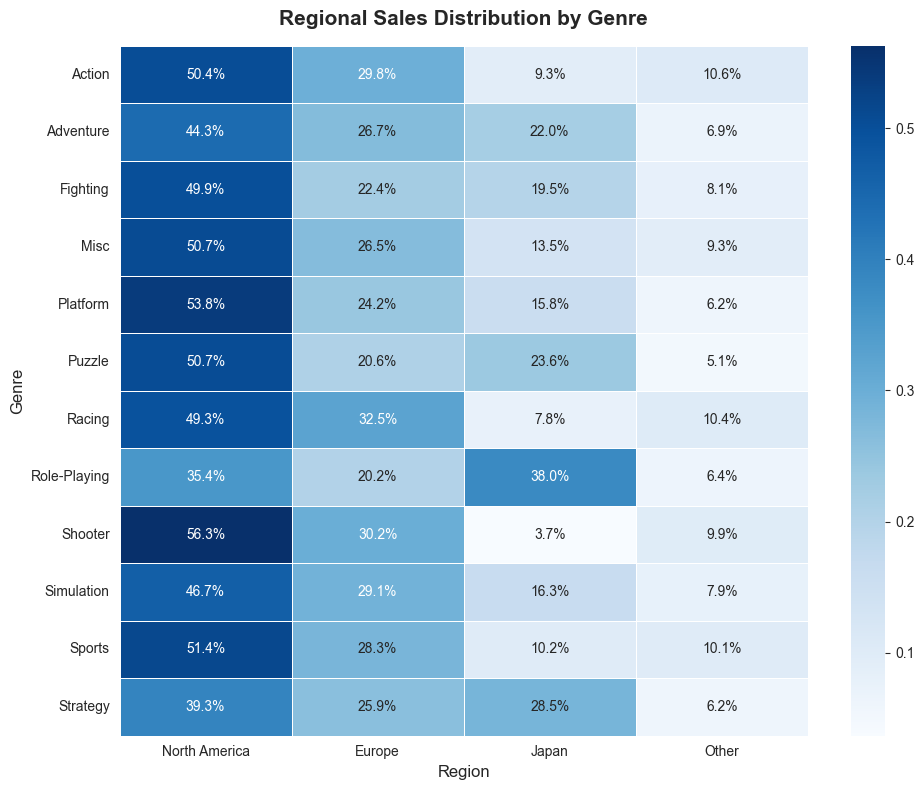

In [10]:
#regional heatmap by genre
# Grouping by genre and summing sales for each region
genre_sales = df1.groupby("Genre")[["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]].sum().round(2)
#normalize sales by rows for relative preferences, not absolute sales
genre_sales_normalized = genre_sales.div(genre_sales.sum(axis=1), axis=0)

#rename columns for better readability
genre_sales_normalized.columns = ["North America", "Europe", "Japan", "Other"]
# Plotting the heatmap
fix, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(genre_sales_normalized, annot=True, fmt=".1%", cmap="Blues", linewidths=0.5, linecolor='white', ax=ax)

ax.set_title("Regional Sales Distribution by Genre", fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Region", fontsize=12)
ax.set_ylabel("Genre", fontsize=12)
ax.tick_params(axis="x", rotation=0)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()

In [11]:
#normalize Critic_Score to a common scale for comparison
df1["Critic_Score_Normalized"] = df1["Critic_Score"] / 10

#group by genre and calculate average scores
genre_scores = (df1.groupby("Genre")[["Critic_Score_Normalized", "User_Score"]].mean().round(2).reset_index().dropna())

#calculating the gap between critic and user scores
genre_scores["Score_Gap"] = (genre_scores["Critic_Score_Normalized"] - genre_scores["User_Score"]).round(2)

genre_scores = genre_scores.sort_values("Score_Gap", ascending=False)

print(genre_scores)




           Genre  Critic_Score_Normalized  User_Score  Score_Gap
10        Sports                     7.20        6.96       0.24
8        Shooter                     7.02        7.04      -0.02
11      Strategy                     7.21        7.30      -0.09
3           Misc                     6.66        6.82      -0.16
6         Racing                     6.80        7.04      -0.24
9     Simulation                     6.86        7.13      -0.27
7   Role-Playing                     7.27        7.62      -0.35
2       Fighting                     6.92        7.30      -0.38
0         Action                     6.66        7.05      -0.39
5         Puzzle                     6.74        7.18      -0.44
4       Platform                     6.81        7.30      -0.49
1      Adventure                     6.53        7.13      -0.60


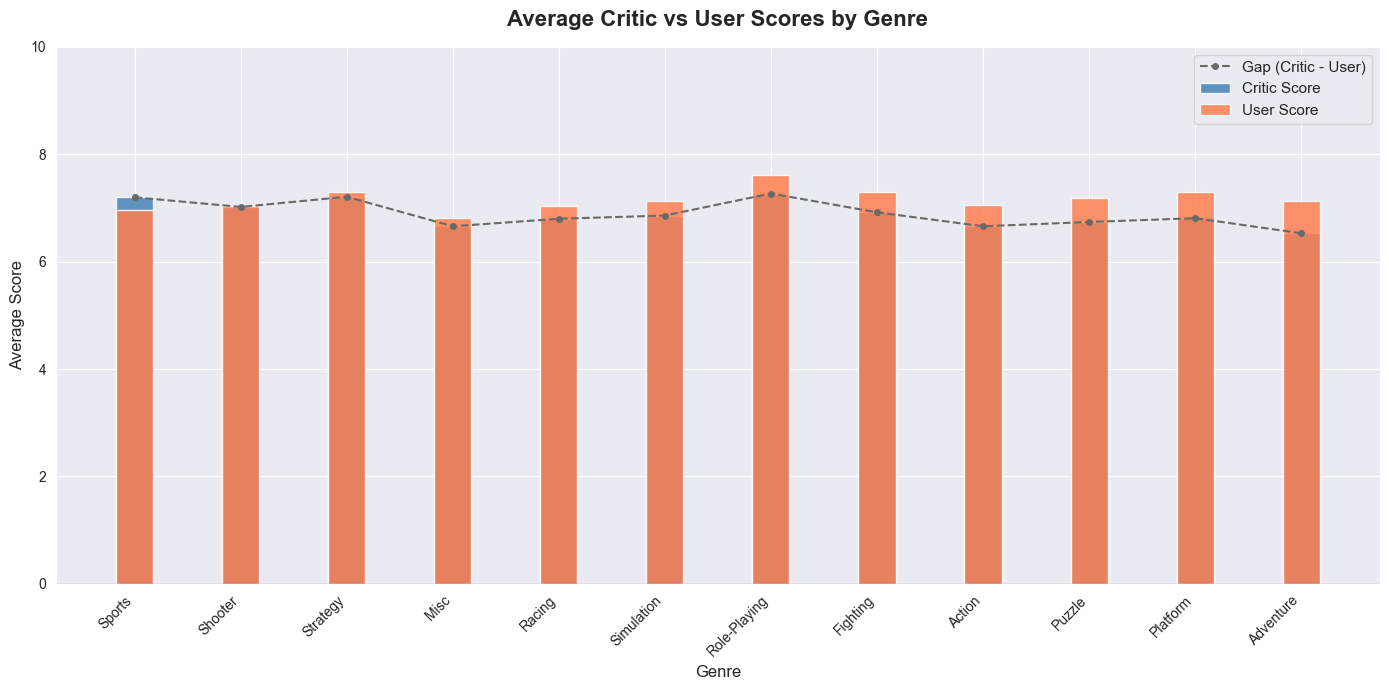

In [12]:
#plotting the score gap by genre
fig, ax = plt.subplots(figsize=(14, 7))
width = 0.35

x= range(len(genre_scores))

bars1 = ax.bar(genre_scores["Genre"], genre_scores["Critic_Score_Normalized"], width=width, label="Critic Score", color="steelblue", alpha=0.85)
bars2 = ax.bar(genre_scores["Genre"], genre_scores["User_Score"], width=width, label="User Score", color="coral", alpha=0.85)

#gap lines
ax.plot(x, genre_scores["Critic_Score_Normalized"], color="dimgray", linewidth=1.5, linestyle = "--", marker="o", markersize=4, label="Gap (Critic - User)")

ax.axhline(0, color="black", linewidth=0.8, linestyle="-")

ax.set_title("Average Critic vs User Scores by Genre", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Genre", fontsize=12)
ax.set_ylabel("Average Score", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(genre_scores["Genre"], rotation=45, ha="right")
ax.legend(fontsize=11)
ax.set_ylim(0, 10)
plt.tight_layout()
plt.show()

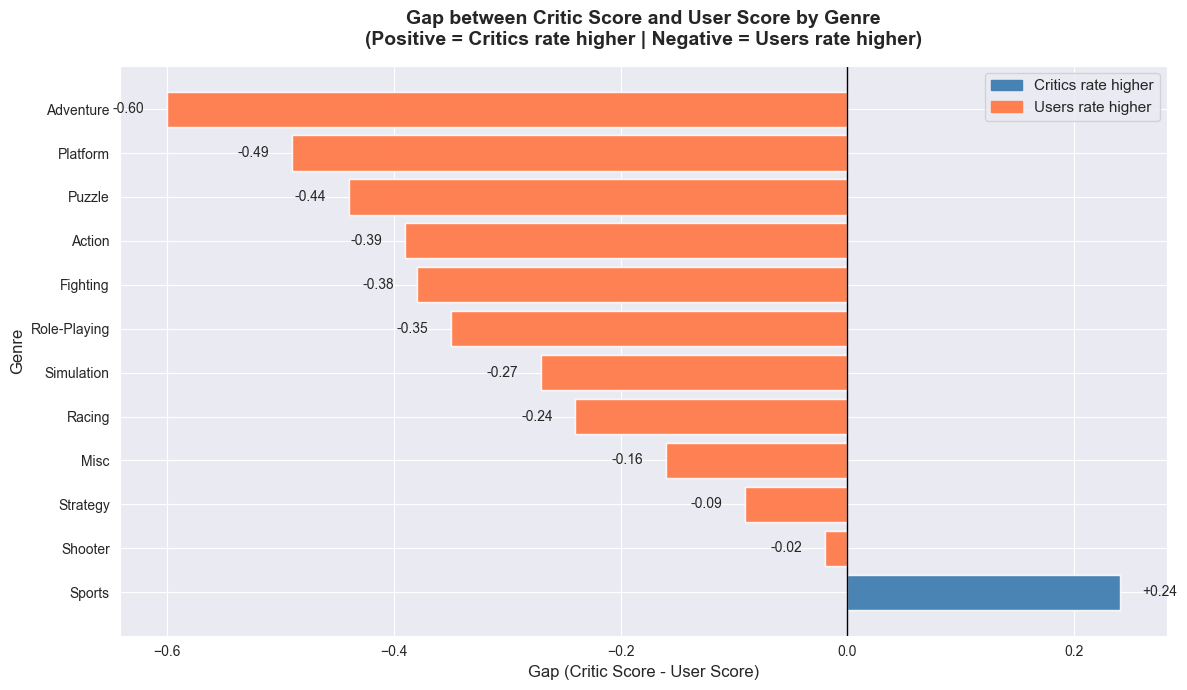

In [13]:
fig, ax = plt.subplots(figsize=(12, 7))

# Conditional color: positive = higher ratings, negative = higher user ratings
colores = ['steelblue' if g > 0 else 'coral' for g in genre_scores['Score_Gap']]

bars = ax.barh(genre_scores['Genre'], 
               genre_scores['Score_Gap'],
               color=colores, alpha=0.85)

bars = ax.barh(genre_scores['Genre'], 
               genre_scores['Score_Gap'],
               color=colores, alpha=0.85)

# Label at the end of each bar
for bar, val in zip(bars, genre_scores['Score_Gap']):
    offset = 0.02 if val >= 0 else -0.02
    ha = 'left' if val >= 0 else 'right'
    ax.text(bar.get_width() + offset, 
            bar.get_y() + bar.get_height()/2,
            f'{val:+.2f}', va='center', ha=ha, fontsize=10)

# Reference line at 0
ax.axvline(x=0, color='black', linewidth=1)

ax.set_title('Gap between Critic Score and User Score by Genre\n(Positive = Critics rate higher | Negative = Users rate higher)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Gap (Critic Score - User Score)', fontsize=12)
ax.set_ylabel('Genre', fontsize=12)

# Manual legend
from matplotlib.patches import Patch
leyenda = [Patch(color='steelblue', label='Critics rate higher'),
           Patch(color='coral', label='Users rate higher')]
ax.legend(handles=leyenda, fontsize=11)

plt.tight_layout()
plt.show()

In [14]:
import plotly
print(plotly.__version__)

6.7.0


In [15]:
#interactive dashboar  - Time series of global sales by genre

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

#---- Data ----

df_time = df1[df1["Year_of_Release"].notna() & (df1["Year_of_Release"]<=2016)]
sales_by_year_genre = df_time.groupby(["Year_of_Release", "Genre"])["Global_Sales"].sum().reset_index()

#---- Plot ----

fig1 = go.Figure()
fig1.add_trace(go.Scatter(x=sales_by_year_genre["Year_of_Release"],
                          y=sales_by_year_genre["Global_Sales"],
                            mode="markers+lines",
                            name ="Global Sales",
                            line=dict(color="steelblue", width=2.5),
                            marker=dict(size=6)),
                            

)

fig1.update_traces(
    fill='tozeroy',
    fillcolor='rgba(70, 130, 180, 0.15)',
    hovertemplate="<b>Year:</b> %{x}<br><b>Sales:</b> %{y:.2f}M<extra></extra>",
)

fig1.update_layout(title="Global Video Game Sales Over the Years", font=dict(size=16),
                   xaxis_title="Year",
                   yaxis_title="Sales (Millions)",
                   hovermode ="x unified",
                   template="plotly_white",

)

fig1.show()



In [16]:
#Dashboard - Market share by platform

platform_sales = df1.groupby("Platform")["Global_Sales"].sum().sort_values(ascending=False).head(10).reset_index()
platform_sales["Market_Share"] = (platform_sales["Global_Sales"] / platform_sales["Global_Sales"].sum() * 100).round(1)

#---- Plot ----
fig2 = go.Figure()

fig2.add_trace(go.Bar(x=platform_sales["Market_Share"],
                      y=platform_sales["Platform"],
                      orientation="h",
                      textposition="outside",
                      marker =dict(color=platform_sales["Market_Share"], colorscale="Blues"),
                      hovertemplate="<b>Platform:</b> %{y}<br><b>Market Share:</b> %{x:.1f}%<extra></extra>"
                      ))

fig2.update_layout(title="Market Share of Top 10 Video Game Platforms", font=dict(size=16),
                   xaxis_title="Market Share (%)",
                     yaxis_title="Platform",
                     yaxis=dict(categoryorder="total ascending"),
                     template="plotly_white",
)
fig2.show()

In [17]:
#Dashboard - Regional heatmap by genre

#---- Data ---
heatmap_data = df1.groupby("Genre")[["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]].sum().round(1)

heatmap_normalized = heatmap_data.div(heatmap_data.sum(axis=1), axis=0,)
heatmap_normalized.columns = ["North America", "Europe", "Japan", "Other"]
#---- Plot ----
fig3 = go.Figure()

fig3.add_trace(go.Heatmap(
    z=heatmap_normalized.values,
    x=heatmap_normalized.columns.tolist(),
    y=heatmap_normalized.index.tolist(),
    colorscale='Blues',
    text=[[f'{v:.1%}' for v in row] for row in heatmap_normalized.values],
    texttemplate='%{text}',
    hovertemplate="<b>Genre:</b> %{y}<br><b>Region:</b> %{x}<br><b>Sales Share:</b> %{z:.1%}<extra></extra>"
))
fig3.update_layout(title="Regional Sales Distribution by Genre", font=dict(size=16),
                   xaxis_title="Region",
                   yaxis_title="Genre",
                   template="plotly_white",
)
fig3.show()

In [18]:
#Dashboard - Critic vs User Scores gap
#---- Data ----
fig4 = go.Figure()
fig4.add_trace(go.Bar(x=genre_scores["Score_Gap"],
                        y=genre_scores["Genre"],
                        orientation="h",
                        marker=dict(
                            color=["steelblue" if g > 0 else "coral" for g in genre_scores["Score_Gap"]],
                            colorscale="RdBu",
                            reversescale=True
                        ),
                        textposition="outside",
                        hovertemplate="<b>Genre:</b> %{y}<br><b>Score Gap:</b> %{x:+.2f}<extra></extra>"
                        ))
fig4.update_layout(title="Critic vs User Scores Gap by Genre", font=dict(size=16),
                   xaxis_title="Score Gap",
                   yaxis_title="Genre",
                   template="plotly_white",
                   shapes=[dict(
                    type='line', x0=0, x1=0,
                     y0=-0.5, y1=len(genre_scores) - 0.5,
                    line=dict(color='black', width=1)
                    )],
                    annotations=[dict(
                        x=0, y=len(genre_scores) - 0.5,
                        xref='x', yref='y',
                        text='Critics rate higher',
                        showarrow=False,
                        font=dict(color='steelblue', size=12),
                        xanchor='left'
                    ), dict(
                        x=0, y=-0.5,
                        xref='x', yref='y',
                        text='Users rate higher',
                        showarrow=False,
                        font=dict(color='coral', size=12),
                        xanchor='right'
                    )]
    )
fig4.show()

In [19]:
#dashboard 

from plotly.subplots import make_subplots

dashboard = make_subplots(rows=2, cols=2, subplot_titles=(
    "Global Sales Over the Years",
    "Market Share by Platform",
    "Regional Sales Distribution by Genre",
    "Critic vs User Scores Gap by Genre"
),
    horizontal_spacing=0.12,
    vertical_spacing=0.10
)
#plot1
dashboard.add_trace(go.Scatter(
    x=sales_by_year['Year_of_Release'],
    y=sales_by_year['Global_Sales'],
    mode='none',
    fill='tozeroy',
    fillcolor='rgba(70,130,180,0.15)',
    showlegend=False,
    hoverinfo='skip'
), row=1, col=1)

dashboard.add_trace(go.Scatter(
    x=sales_by_year['Year_of_Release'],
    y=sales_by_year['Global_Sales'],
    mode='lines+markers',
    line=dict(color='steelblue', width=2),
    marker=dict(size=4),
    showlegend=False,
    hovertemplate='<b>Año:</b> %{x}<br><b>Ventas:</b> $%{y:.1f}M<extra></extra>'
), row=1, col=1)

#plot2

dashboard.add_trace(go.Bar(
    x=platform_sales['Market_Share'],
    y=platform_sales['Platform'],
    orientation='h',
    marker=dict(color=platform_sales['Market_Share'], colorscale='Blues'),
    hovertemplate='<b>%{y}</b><br>Market Share: %{x:.1f}%<extra></extra>'
), row=1, col=2)

#plot3
dashboard.add_trace(go.Heatmap(
    z=heatmap_normalized.values,
    x=heatmap_normalized.columns.tolist(),
    y=heatmap_normalized.index.tolist(),
    colorscale='Blues',
    text=[[f'{v:.1%}' for v in row] for row in heatmap_normalized.values],
    texttemplate='%{text}',
    hovertemplate='<b>Genre:</b> %{y}<br><b>Region:</b> %{x}<br><b>Sales Share:</b> %{z:.1%}<extra></extra>'
), row=2, col=1)

#plot4
dashboard.add_trace(go.Bar(
    x=genre_scores['Score_Gap'],
    y=genre_scores['Genre'],
    orientation='h',
    marker=dict(
        color=['steelblue' if g > 0 else 'coral' for g in genre_scores['Score_Gap']],
        colorscale='RdBu',
        reversescale=True
    ),
    hovertemplate='<b>Genre:</b> %{y}<br><b>Score Gap:</b> %{x:+.2f}<extra></extra>'
), row=2, col=2)

#layout
dashboard.update_layout(
    title='Video Game Sales Analysis Dashboard',
    title_font_size=20,
    showlegend=False,
    height=900,
    width=1200,
    template='plotly_white',
    shapes=[dict(
        type='line', x0=0, x1=0, y0=-0.5, y1=len(genre_scores) - 0.5,
        line=dict(color='black', width=1)
    )],
    
)
dashboard.update_xaxes(range=[1979, 2017], row=1, col=1)
dashboard.show()


## Key findings


**Global sales over time**

Sales peaked starting in 1995, we see a sharp decline in 2000 and a significant rise during the console wars era (2005–2008). Sales have been falling steadily since around 2012. 
Note: data only covers through 2016, so the full recovery or continued decline remains unknown.

**Platform Market Share**
The PS2 leads the market with an 18.5% followed by the Xbox 360, the PS3, and the Wii—all products from the same era of the console wars. The PS4’s low share is due to incomplete data; at the time this dataset was compiled, it had only been on the market for three years.

**Regional Sales Distribution**

In North America there is a sales peak in the shooter genre, although there is some parity in other genres; similarly in Europe, although its peak is in the racing genre given its culture; and finally, Japan stands out for its sales peaks in RPGs and strategy games and a sharp decline in other genres, excluding puzzle and adventure games.

**Critic vs User Score GAP**

Users rate almost every genre higher than critics, except with Adventure and Platform showing the largest gaps. Sports is the only genre where critics rate higher, possibly due to annual franchise fatigue among players.
